# Bayesian Neural Networks

Working with Bayesian neural networks in ProbJax.

In [1]:
%reload_ext autoreload
%autoreload 2

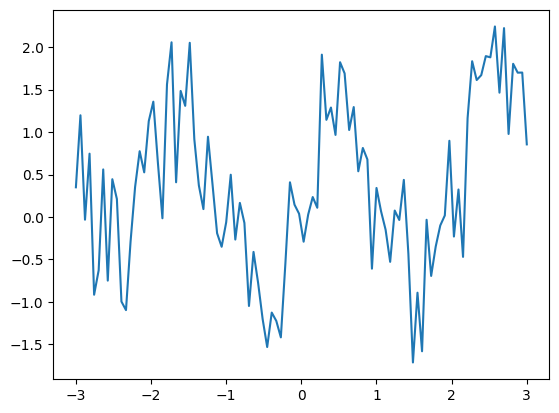

In [39]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from flax import nnx

from probjax.nn import MLP

X = np.linspace(-3, 3, 100)[:, None]
Y = 0.1 * X**2 + 0.1 + jnp.sin(3 * X) + np.random.normal(0, 0.5, size=X.shape)
plt.plot(X,Y)

In [100]:
model = MLP([1,20,20,20,1], rngs=nnx.Rngs(0))
nnx.display(model)

In [101]:
def logdensity_fn(model, sigma: float = 0.5):
    y = model(X)
    # L2 regularization (Gaussian prior) - properly sum squared weights
    l2_reg = jax.tree_util.tree_reduce(lambda acc, y: acc + jnp.sum(y**2), model, 0.0)
    return -0.5*jnp.sum((Y - y)**2/sigma**2) - 0.5*l2_reg


In [102]:
jax.jit(logdensity_fn)(model)

Array(-280.06677, dtype=float32)

In [109]:
import jax

from probjax.inference.mcmc import dynamic_hmc
from probjax.inference.mcmc_runner import MCMC

kernel = dynamic_hmc(logdensity_fn, average_integration_steps=100)

state = kernel.init(model, rng_key=jax.random.PRNGKey(0))
params = kernel.init_params(model, step_size=0.0001)

In [110]:
state, params = kernel.fit_params(jax.random.key(0), state, params, 80_000)

In [111]:
params

HMCParams(step_size=Array(0.00114207, dtype=float32, weak_type=True), inverse_mass_matrix=Array([0.9951752 , 0.9301735 , 0.96228427, 0.9805875 , 1.1290572 ,
       0.8598586 , 0.9269876 , 0.9841191 , 0.9781997 , 0.9645284 ,
       0.9792936 , 1.0135826 , 0.85807943, 0.9309739 , 0.9735887 ,
       1.0170708 , 1.0321288 , 0.9089017 , 1.0204887 , 1.0614977 ,
       0.6614186 , 0.6909857 , 0.5754504 , 0.656461  , 0.6694632 ,
       0.7281207 , 0.6747234 , 0.6750729 , 0.6160337 , 0.6173434 ,
       0.7270557 , 0.7149338 , 0.68097955, 0.73729056, 0.67333937,
       0.6803823 , 0.6705115 , 0.5957604 , 0.57324934, 0.6397739 ,
       0.95935965, 0.974553  , 0.846176  , 1.1002201 , 0.9450694 ,
       0.9710621 , 1.0282338 , 0.9644452 , 1.0386373 , 1.0362732 ,
       0.9465224 , 0.9592779 , 1.0359993 , 0.99297494, 1.0341536 ,
       1.0087682 , 1.0064787 , 0.9766943 , 1.0326499 , 0.9964344 ,
       0.94224995, 0.98998886, 0.9645714 , 1.0365903 , 0.9608282 ,
       0.962057  , 1.0931945 , 0.975975

In [112]:
mcmc = MCMC(kernel, verbose=True)

In [113]:
samples, state = mcmc.sample(jax.random.PRNGKey(1), state, 500, params, thin=20)

Progress: |██████████████████████████████████████████████████| 100.00% logdensity: -1949.66 acceptance_rate: 0.01

(-3.5, 3.5)

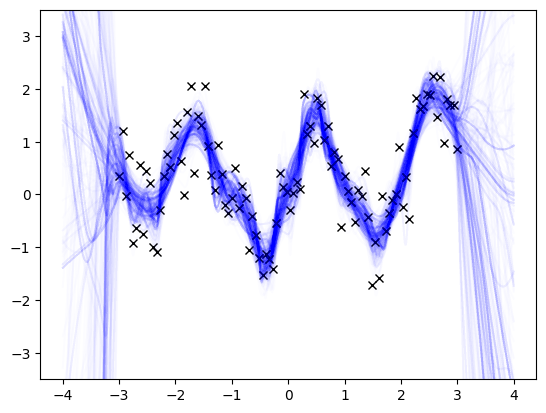

In [115]:
def predict(model, X):
    return model(X)
X_test = np.linspace(-4, 4, 1000)[:, None]
preds = jax.vmap(predict, in_axes=(0, None))(samples, X_test)
plt.plot(X, Y, 'kx')
_ = plt.plot(X_test, preds[...,0].T, 'b', alpha=0.01)
plt.ylim(-3.5, 3.5)